In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Mall_Customers.csv')
print ("5 premières lignes")
display(df.head())
print("\n Informations sur le colonnes")
df.info()
print("\n Statistqiues descriptives ")
display(df.describe())

5 premières lignes


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



 Informations sur le colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

 Statistqiues descriptives 


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
from sklearn.preprocessing import StandardScaler
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=['Revenus_normalise', 'Score_normalise'])

print("Données brutes")
display(X.head())

print("\n Données préparées pour le K-means")
display(df_scaled.head())

Données brutes


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40



 Données préparées pour le K-means


,Revenus_normalise,Score_normalise
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


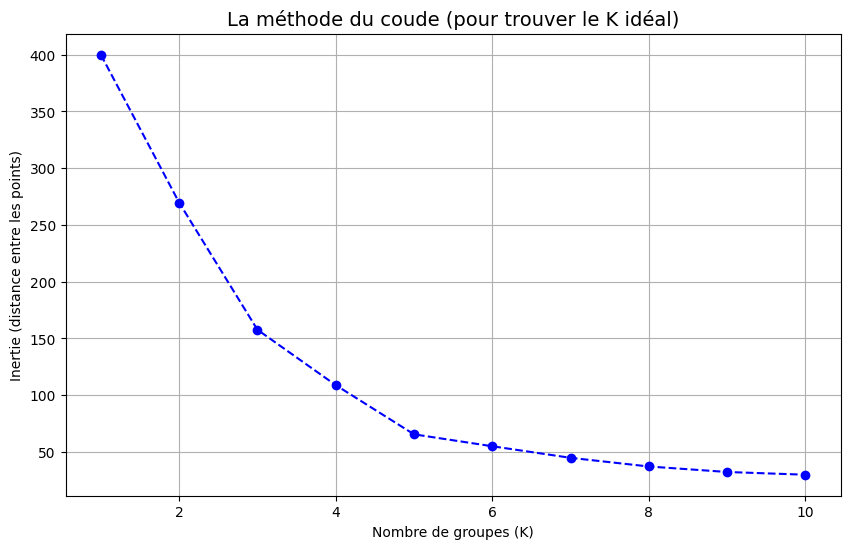

In [9]:
from sklearn.cluster import KMeans
erreurs = []
for k in range (1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  erreurs.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1, 11), erreurs, marker='o', linestyle='--', color='b')
plt.title('La méthode du coude (pour trouver le K idéal)', fontsize=14)
plt.xlabel('Nombre de groupes (K)')
plt.ylabel('Inertie (distance entre les points)')
plt.grid(True)
plt.show()

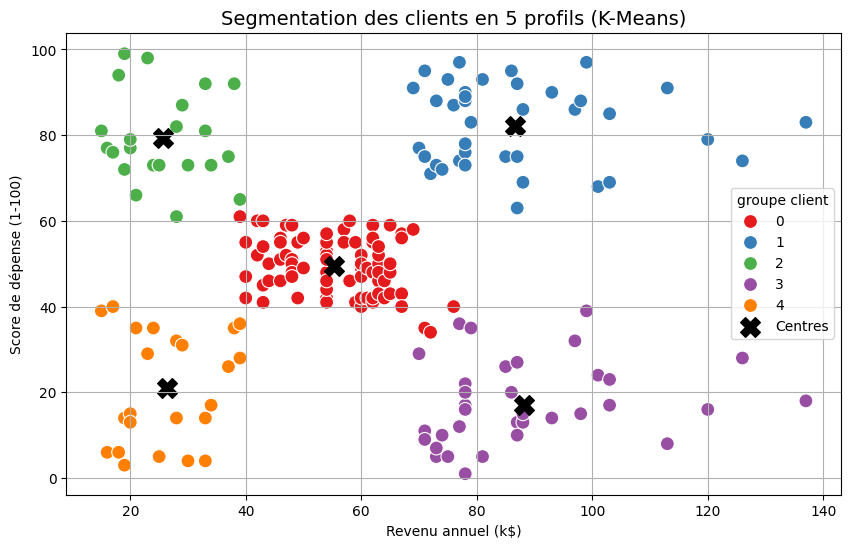

In [14]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)
centres = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centres[:, 0], centres[:, 1], c='black', s=200, marker='X', label='Centres')

plt.title('Segmentation des clients en 5 profils (K-Means)', fontsize=14)
plt.xlabel('Revenu annuel (k$)')
plt.ylabel('Score de dépense (1-100)')
plt.legend(title='groupe client')
plt.grid(True)
plt.show()

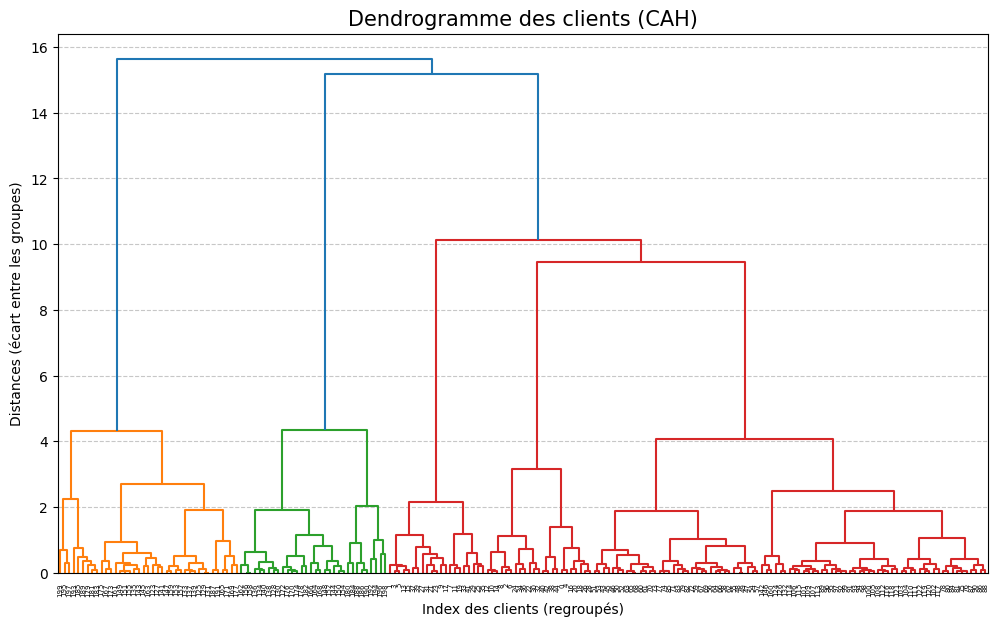

In [16]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))

plt.title('Dendrogramme des clients (CAH)', fontsize=15)
plt.xlabel('Index des clients (regroupés)')
plt.ylabel('Distances (écart entre les groupes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
import plotly.express as px
from sklearn.cluster import KMeans

X_3D = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_3D_scaled = scaler.fit_transform(X_3D)
kmeans_3d = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_3D'] = kmeans_3d.fit_predict(X_3D_scaled)
df['Cluster_3D'] = df['Cluster_3D'].astype(str)

fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster_3D',
    title='Segmentation 3D interactive : âge, revenu et score',
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(width=900, height=700)
fig.show()

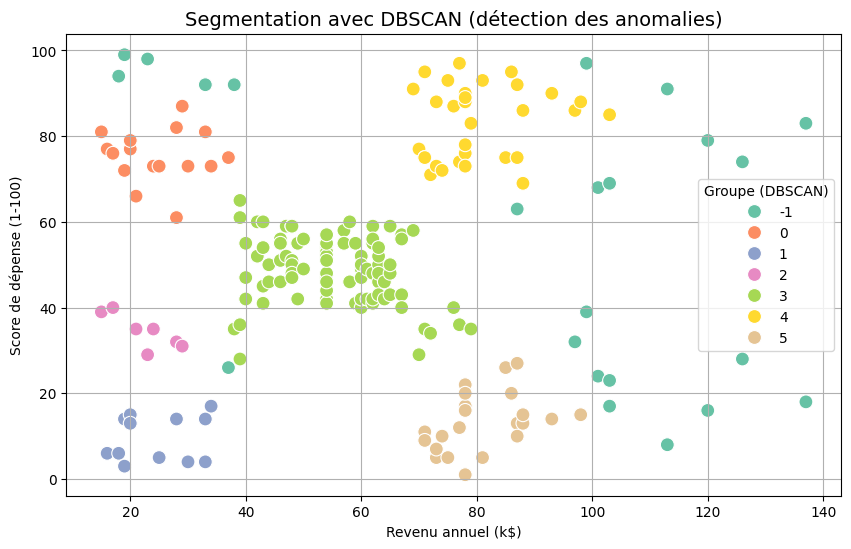

In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.35, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster_DBSCAN',
    data=df,
    palette='Set2',
    s=100
)
plt.title('Segmentation avec DBSCAN (détection des anomalies)', fontsize=14)
plt.xlabel('Revenu annuel (k$)')
plt.ylabel('Score de dépense (1-100)')
plt.legend(title='Groupe (DBSCAN)')
plt.grid(True)
plt.show()